In [60]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

import pickle

In [62]:
df = pd.read_csv("C:/Users/HP/Downloads/archive (1)/House Price India.csv")

df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [63]:
df.shape

(14619, 23)

In [64]:
df.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

In [65]:
#Drop Unnecessary Columns

df.columns = df.columns.str.strip()

In [66]:
#Drop Unnecessary Columns
df = df.drop(columns=['id','Date'], errors='ignore')

In [67]:
#Features and Target
X = df.drop(columns=['Price'])
y = df['Price']

In [68]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [69]:
#️Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Train Random Forest Mode
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

In [58]:
#Predict Test Data
pred = rf.predict(X_test)

In [59]:
#Evaluate Model
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

# Print Results
print("Random Forest")

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

Random Forest
MAE  : 69771.59436730506
MSE  : 17694822195.17678
RMSE : 133021.88615102696
R2 Score : 0.8804372169812411


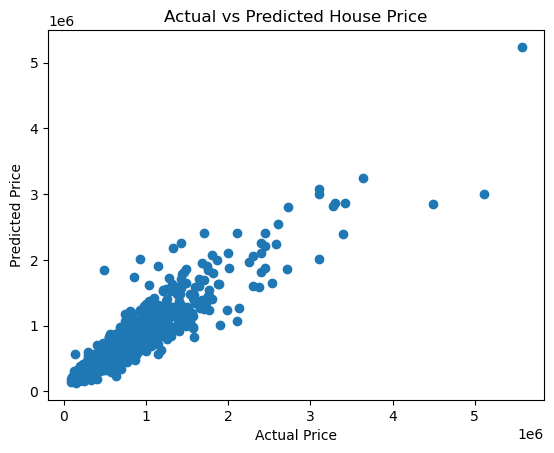

In [47]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

In [48]:
#predict using  a new house
cols = X.columns

new_house = pd.DataFrame([[
3,2,1800,5000,2,0,2,3,7,1500,300,
2005,0,400001,19.07,72.87,1700,4500,3,20
]], columns=cols)

# scale input
new_house_scaled = scaler.transform(new_house)

# predict price
prediction = model.predict(new_house_scaled)

print("Predicted Price:", prediction)

Predicted Price: [297817.36871429]


In [50]:
#save 
with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [51]:
#load the save model
with open("house_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("scaler.pkl", "rb") as file:
    loaded_scaler = pickle.load(file)

In [52]:
#Predict Using Loaded Model
new_house_scaled = loaded_scaler.transform(new_house)

prediction = loaded_model.predict(new_house_scaled)

print("Predicted Price from Loaded Model:", prediction)

Predicted Price from Loaded Model: [297817.36871429]


In [53]:
#Predict Test Data with Loaded Model
predictions = loaded_model.predict(X_test)

print(predictions)

[ 584073.00895165  434073.66        358939.84591908 ...  658580.43284895
  461650.03468254 1843050.        ]
